## Demo Diffusion models generative AI

Author: alberto.suarez@uam.es
Date: 2025-03-02

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from functools import partial 

import torch
from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision.transforms import functional

import diffusion_process as dfp

from diffusion_utilities import (
    plot_image_grid,
    plot_image_evolution,
    animation_images,
)


n_threads = torch.get_num_threads()
print('Number of threads: {:d}'.format(n_threads))

# device ='cpu' 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Number of threads: 8


In [2]:
# Dataset MINST
data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)
print(type(data))

<class 'torchvision.datasets.mnist.MNIST'>


In [3]:
# Create a subset dataset composed of only images of one of the digits
digit = 3
indices_digit = torch.where(data.targets == digit)[0]  

data_train = Subset(data, indices_digit)
print(type(data_train))

<class 'torch.utils.data.dataset.Subset'>


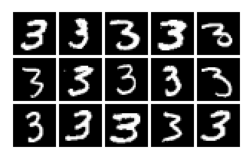

In [4]:
# Visualize training images
n_rows = 3 
n_cols = 5

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize =(3, 3),
    n_rows=n_rows, 
    n_cols=n_cols,
)

###  Diffusion process

In [5]:
sigma = 25.0

def bm_drift_coefficient(x_t, t):
    return torch.zeros_like(x_t)  # drift term: f(x_t, t) = 0

def bm_diffusion_coefficient(t, sigma):
    return sigma**t  # diffusion coefficient: g(t) = sigma^t

def bm_mu_t(x_0, t):
    return x_0  # conditional mean: mu_t(x_0) = x_0

def bm_sigma_t(t, sigma):
    return torch.sqrt(0.5 * (sigma**(2 * t) - 1.0) / np.log(sigma))
    # sigma_t = sqrt(integral_de_0-t (g(s)^2 ds))

drift_coefficient = bm_drift_coefficient
diffusion_coefficient = lambda t: bm_diffusion_coefficient(t, sigma)
mu_t = bm_mu_t
sigma_t = lambda t: bm_sigma_t(t, sigma)

diffusion_process = dfp.GaussianDiffussionProcess(
    drift_coefficient,
    diffusion_coefficient,
    mu_t,
    sigma_t,
)

In [6]:
# Define the score model

from score_model import ScoreNet

# Create the neural network s_theta(x, t) ≈ grad_x log p_t(x)

score_model = torch.nn.DataParallel(  # Enables multi-GPU usage if available
    ScoreNet(
        # Neural network that takes a noisy image x_t and time t,
        # and returns the score s(x, t) = grad_x log p_t(x)
        marginal_prob_std=partial(
            bm_sigma_t, 
            sigma=sigma
        )  # 'partial' is used to fix the value of sigma in bm_sigma_t
    )
)

# Move the model to the selected device (CPU or GPU)
score_model = score_model.to(device)

In [7]:
# Train the network to learn the score function (interpreted as denoising)

from torch.optim import Adam
import torchvision.transforms as transforms
from tqdm import trange  # progress bars

batch_size = 64

# Split the training data into mini-batches
data_loader = DataLoader(
    data_train,
    batch_size=batch_size,   # process 64 images per iteration
    shuffle=True,            # shuffle data every epoch to improve learning
    num_workers=n_threads,   # number of parallel workers for data loading
)

learning_rate = 1.0e-3
optimizer = Adam(
    score_model.parameters(),
    lr=learning_rate
)  # Adam optimizer to update model parameters

n_epochs = 300
tqdm_epoch = trange(n_epochs)  # progress bar for epochs

for epoch in tqdm_epoch:  # loop over training epochs
    avg_loss = 0.0        # accumulator for total loss in the epoch
    num_items = 0         # total number of processed samples

    for x, y in data_loader:  # iterate over mini-batches (x: images, y: labels)
        x = x.to(device)      # move images to device (CPU or GPU)

        loss = diffusion_process.loss_function(score_model, x)
        # compute the loss:
        # sample time t, generate x_t by adding noise,
        # the network predicts the score and denoising error is computed

        optimizer.zero_grad()  # reset accumulated gradients
        loss.backward()        # compute gradients of loss w.r.t. model parameters
        optimizer.step()       # update model parameters using the optimizer

        avg_loss += loss.item() * x.shape[0]
        # loss.item() converts tensor to scalar
        # multiply by batch size to accumulate total loss

        num_items += x.shape[0]  # accumulate total number of processed samples

    tqdm_epoch.set_description(
        'Average Loss: {:5f}'.format(avg_loss / num_items)
    )  # display average loss for the epoch in the progress bar

    torch.save(score_model.state_dict(), 'check_point.pth')
    # save model state (learned parameters)

Average Loss: 16.525192: 100%|██████████| 300/300 [25:11<00:00,  5.04s/it]


In [13]:
# Sample from the trained model

n_images = 3

# check_point = torch.load('model_digit_3_500_epochs.pth', map_location=device)
# score_model.load_state_dict(check_point)

def backward_drift_coefficient(x_t, t, diffusion_coefficient):
    g_t = diffusion_coefficient(t).view(-1, 1, 1, 1)
    return drift_coefficient(x_t, t) - (g_t ** 2) * score_model(x_t, t)

T = 1.0
# initial sample x_T ~ N(0, sigma_T^2 I)
sigma_T = bm_sigma_t(torch.ones(n_images, device=device)*T, sigma).view(-1, 1, 1, 1)
image_T = torch.randn(n_images, 1, 28, 28, device=device) * sigma_T  # initial images x_T ~ N(0, sigma_T^2)


with torch.no_grad():
    times, synthetic_images_t = dfp.euler_maruyama_integrator(
        image_T,
        t_0 = T, 
        t_end = 1.0e-3,
        n_steps= 500,
        drift_coefficient=partial(
            backward_drift_coefficient,
            diffusion_coefficient=diffusion_coefficient,
        ),
        diffusion_coefficient=diffusion_coefficient, 
    )

print(type(synthetic_images_t))
print(synthetic_images_t.shape)

<class 'torch.Tensor'>
torch.Size([3, 1, 28, 28, 501])


What we can observe is a tensor of shape [3, 1, 28, 501], where 3 corresponds to the number of samples (images), each with 1 channel (grayscale) and a spatial size of 28x28 pixels, evaluated over 501 time steps (corresponding to the 500 integration steps plus the initial state).

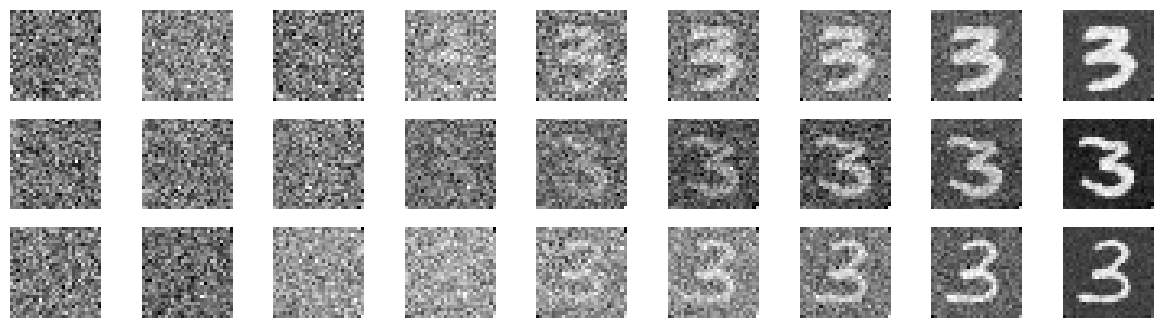

In [16]:
_ = plot_image_evolution(
    images=synthetic_images_t.detach().cpu(),
    n_images=n_images,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 490, 500],
    figsize=(15, 4),
)